# Homework 10


**Concepts covered:**

pandas `DataFrame`s: initialization,  descriptive statistics, line plot, scatter plot, histogram, column-wise operations, row-wise operations.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

While we encourage you to use AI to generate practice problems, **we recommend against using generative AI in the strongest terms** to solve any part of this assignment. The goal of this assignment is for you to learn these concepts, and while using AI may help you obtain solutions to these problems, you will cheat yourself out of the learning that comes from working through the problems yourself.

**Sample Output:**

For each problem description, a sample output has been included to show what the expected output should be.
Some functions have test cases provided for you to test with, so no sample output has been included for those.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [38]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.close("all")

# access to data file(s); update to week-10
df_stock_prices = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/SPY.csv")
df_stock_prices.index = pd.to_datetime(df_stock_prices["date"], unit='s')

df_weather = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/02215_weather.csv")
df_weather.index = pd.to_datetime(df_weather["datetime"], format="%m/%d/%y")


df_econ_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/annual_data.csv")
df_econ_data.index = df_econ_data["Year"]



**Note: This will be partially manually graded, so please allow some time before getting your full grade.**

**Review Problem 1**

**Concept:** *matplotlib, scatter plot*


**Task:**

Create a scatter plot that produces a spiral/cyclone pattern.

* Generate radius values that gradually increase
* Generate angle values that rotate around the origin
* Compute:
  * x = radius × cos(angle)
  * y = radius × sin(angle)
* Plot the points using plt.scatter()
* Add a title

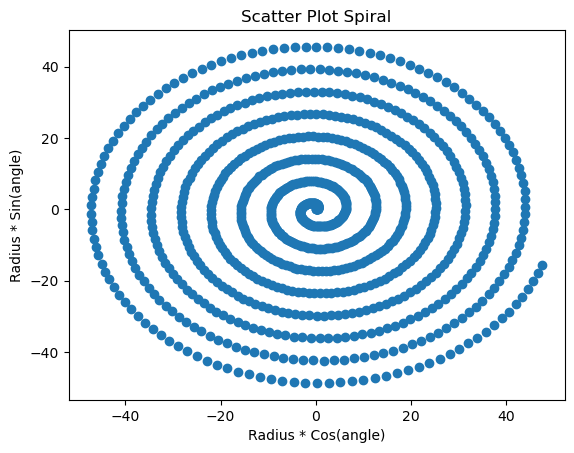

In [88]:
''' 
a scatter plot that produces a spiral pattern
'''
# generates a list of radius values
radius = np.arange(0, 50, 0.05)

#generates a list of angle values
angle = np.arange(0, 50, 0.05)

# computes x coordinates radius and cosine of angle
x = radius * np.cos(angle)

# computes x coordinates radius and sine of angle
y = radius * np.sin(angle)

# plots graph and adds title and labels
plt.scatter(x, y)
plt.title('Scatter Plot Spiral')
plt.xlabel('Radius * Cos(angle)')
plt.ylabel('Radius * Sin(angle)')
plt.show()

**Review Problem 2**

**Concept:** *reading CSV data, matplotlib, line graph*

**Task:**

Write a function `read_and_plot_column(filename, column_name)` that:
* Opens a CSV file (do **not** use pandas)
* Extracts the values from the specified column
* Casts all values to `float`
* Plots the values using `plt.plot()`
* Adds a title
* Displays the plot

In [26]:
def read_and_plot_column(filename, column_name):
  ''' 
  reads CSV file, extracts values casting them as a float annd plotting their values
  '''
  # opening CSV to read
  with open(filename, 'r') as file:

    #read through the CSV
    rows = file.readlines()

    #read the headers
    headers = rows[0].strip().split(",")

    #this will get the position of each header so the value can be extracted correctly
    header_ind = headers.index(column_name) 

    #putting our values in a list to plot
    values =[]
  
    # going through each line, starting after the header
    for line_row in rows[1:]:

      # take the line and strip the white space and replace with a comma
      new_line = line_row.strip().split(",")

      # take the values at the index, change to float, add to the values list
      values.append(float(new_line[header_ind]))
      
    # a variable to take the column name values that were asked for
    # x_column = file(column_name, dtype='float')

    #plot all values
    plt.plot(values)

    #add title, labels
    plt.title("Weather: Max Temperatures")
    plt.xlabel("Entry #")
    plt.ylabel("Temperature")
    plt.show()


  


Test case for problem 2

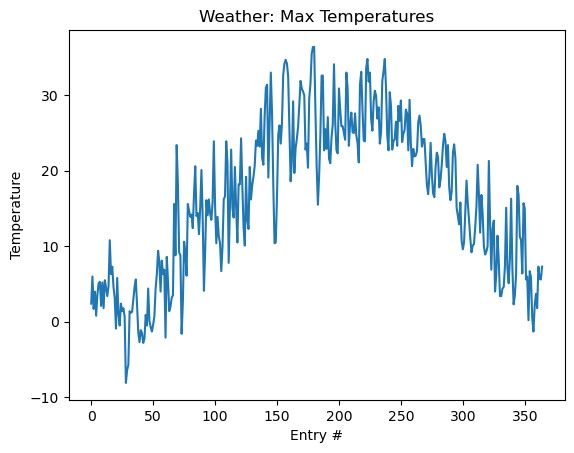

In [27]:
# test case:
read_and_plot_column("02215_weather.csv", "tempmax")


**Problem 3**

**Concept:** *Examining Data*


**Task:**

Using `df_weather`:
* Print the first 5 rows
* Print the last 5 rows

**Important:**

Store your results in the variables below and print them. The autograder will check for these variables.
* `df_weather_head`
* `df_weather_tail`

**Sample Output:**

If the following was your dataframe:

```
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50

```

The following will be your output:

```
FIRST 5 ROWS:
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50

LAST 5 ROWS:
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```


In [75]:
# will display first 5 rows
df_weather_head = df_weather.head()

# will display the last 5 rows
df_weather_tail = df_weather.tail()

# prints first 5 rows
print("FIRST 5 ROWS:")
print(df_weather_head)

#prints last 5 rows
print("LAST 5 ROWS:")
print(df_weather_tail)

FIRST 5 ROWS:
           datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
datetime                                                                  
2021-01-01   1/1/21      2.4     -2.4   0.5           2.3          -6.8   
2021-01-02   1/2/21      6.0      0.1   3.9           3.8          -5.1   
2021-01-03   1/3/21      1.7     -1.4   0.1          -1.7          -5.7   
2021-01-04   1/4/21      4.0     -0.6   1.0          -0.3          -5.7   
2021-01-05   1/5/21      0.8     -1.0  -0.3          -3.9          -6.1   

            feelslike  dew  humidity  precip  ...  solarenergy  uvindex  \
datetime                                      ...                         
2021-01-01       -1.9 -5.4      65.0   0.897  ...          4.8        3   
2021-01-02       -0.4  1.6      85.7  12.092  ...          2.4        1   
2021-01-03       -3.8 -3.0      79.7   0.794  ...          1.5        1   
2021-01-04       -3.5 -2.3      78.9   0.000  ...          4.3        3   
2021-01-05

**Problem 4**

**Concept:** *Accessing `DataFrame` columns*


**Task:**

Using `df_weather`:
* Print all column names
* Create a list of columns that contain the substring `"temp"`
* Create a new DataFrame using only those columns
* Print the result

**Important:**

Store your result in the variable below and print it. The autograder will check for this variable.
* `df_weather_temp_cols`

**Sample Output:**

If the following were your column names and dataframe:
```
Index(['product', 'color', 'price'], dtype='object')

   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```

And you selected the columns that matched your condition, the following could be your output:
```
Index(['product', 'color', 'price'], dtype='object')

   product  color
P1   shirt   blue
P2   pants  black
P3     hat    red
P4  jacket  green
P5   shoes  white
```



In [77]:
# prints all of the column names
print(df_weather.columns)

# prints a list of all columns like "temp"
print()
print(df_weather.filter(like="temp").columns)

# create a new df that contains substring temp
df_weather_temp_cols = pd.DataFrame(df_weather.filter(like="temp"))

# a empty line, then printing the variable for all dates and all substrings
print()
df_weather_temp_cols

Index(['datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='object')

Index(['tempmax', 'tempmin', 'temp'], dtype='object')



,tempmax,tempmin,temp
datetime,,,
2021-01-01,2.4,-2.4,0.5
2021-01-02,6.0,0.1,3.9
2021-01-03,1.7,-1.4,0.1
2021-01-04,4.0,-0.6,1.0
2021-01-05,0.8,-1.0,-0.3
...,...,...,...
2021-12-27,1.8,-1.1,0.5
2021-12-28,7.3,0.6,3.8
2021-12-29,5.7,2.5,4.3


**Problem 5**

**Concept:** *Descriptive Statistics*


**Task:**

Using `df_weather`:

* Display descriptive statistics for all columns

**Important:**

Store your result in the variable below and print it. The autograder will check for this variable.
* `df_weather_descriptive_statistics`

**Sample Output:**

If the following was your dataframe:
```
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```
The following will be your output:
```
DESCRIPTIVE STATISTICS:
           price
count   5.000000
mean   36.000000
std    19.235384
min    15.000000
25%    20.000000
50%    35.000000
75%    50.000000
max    60.000000

```



In [80]:
# gets descriptive statistics of df_weather
df_weather_descriptive_statistics = df_weather.describe()
df_weather_descriptive_statistics

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,...,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,0.0,365.000000
mean,16.215616,8.451781,12.292055,15.490411,6.158904,10.823288,5.084384,64.213151,3.654545,44.657534,...,25.798904,203.615890,1015.813699,64.498082,14.677808,128.181096,11.062740,4.956164,NaN,0.507178
std,10.236355,9.420414,9.609977,11.918353,11.772183,11.611922,10.629004,15.479875,9.119694,49.782003,...,8.894244,103.839985,7.188829,25.233514,2.424786,76.667991,6.617744,2.383147,NaN,0.309059
min,-8.100000,-14.300000,-10.400000,-16.700000,-25.600000,-20.300000,-21.000000,26.000000,0.000000,0.000000,...,10.800000,2.000000,992.400000,0.800000,4.400000,8.100000,0.700000,0.000000,NaN,0.000000
25%,7.100000,0.500000,3.900000,5.300000,-4.100000,0.400000,-3.800000,54.400000,0.000000,0.000000,...,19.900000,106.200000,1011.100000,45.500000,14.800000,65.800000,5.700000,3.000000,NaN,0.250000
50%,16.600000,8.900000,12.300000,16.600000,6.700000,12.100000,4.900000,64.400000,0.000000,0.000000,...,24.000000,232.200000,1015.400000,65.300000,15.800000,115.100000,9.800000,5.000000,NaN,0.500000
75%,24.200000,17.100000,20.400000,24.200000,17.100000,20.400000,14.500000,76.300000,2.243000,100.000000,...,30.600000,289.700000,1020.700000,87.300000,16.000000,192.200000,16.600000,7.000000,NaN,0.760000
max,36.400000,26.200000,31.200000,40.600000,26.200000,34.500000,22.100000,95.100000,83.845000,100.000000,...,89.000000,359.400000,1036.000000,100.000000,16.000000,303.600000,26.200000,9.000000,NaN,1.000000


**Problem 6**

**Concept:** *plotting, line graphs (time series)*


**Task:**

Using `df_weather`:
* Plot the `tempmax` column
* Add a title
* Display the plot

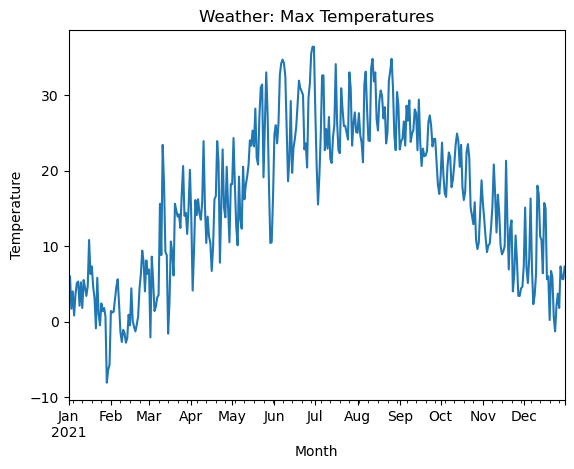

In [87]:
# plot the tempmax column of df_weather
df_weather['tempmax'].plot(title='Weather: Max Temperatures')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()

**Problem 7**

**Concept:** *plotting, line graphs (time series)*


**Task:**

Using `df_weather`:
* Plot the `precip` column
* Add a title
* Display the plot


In [ ]:
# plot the precip column of df_weather



**Problem 8**

**Concept:** *histogram*


**Task:**

Using `df_weather`:
* Create a histogram of the `feelslike` column
* Use 25 bins
* Add a title
* Display the plot


In [ ]:
# Your Solution




**Problem 9**

**Concept:** *pie chart*


**Task:**

* Print value counts of `df_weather['conditions']`
* Create a pie chart of the values
* Make sure to include labels
* Print value counts of `df_econ_data['PresidentParty']`
* Create a pie chart of the values
* Make sure to include labels

**Sample Output:**

If one of your columns contained the following values:
```
blue, black, red, green, white
```
The following could be your printed value counts:
```
blue     1
black    1
red      1
green    1
white    1
Name: color, dtype: int64
```
If another column contained the following values:
```
summer, winter, summer, spring, winter
```
The following could be your printed value counts:
```
summer    2
winter    2
spring    1
Name: season, dtype: int64
```

In [ ]:
# Your Solution





**Problem 10**

**Concept:** *creating new column data, extracting columns, plotting*


**Task:**

Using `df_weather`:
* Write a helper function to extract time (in hours) from a datetime string and convert it to decimal hours (float)
* Convert time using:

    `hours + (minutes / 60) + (seconds / 3600)`
* Create a new DataFrame with the same index as `df_weather`
* Add the following columns:
  * `sunrise` (converted to float)
  * `sunset` (converted to float)
  * `tempmin` (copied directly from `df_weather`)
* Plot all columns together using `.plot()`


**Sample Output:**

This is similar to how your new dataframe should look before plotting:

```
   start_time  end_time  price
P1       8.25     17.50     20
P2       8.50     17.75     35
P3       9.00     18.00     15
P4       9.25     18.25     60
P5       9.50     18.50     50
```

In [ ]:
# Your Solution




**Problem 11**

**Concept:** *descriptive statistics*


**Task:**


Using `df_stock_prices`:
* Print the first 5 rows
* Display descriptive statistics

**Important:**

Store your results in the variables below and print them. The autograder will check for these variables.
* `df_stock_prices_head`
* `df_stock_prices_descriptive_statistics`

**Sample Output:**


If the following was your dataframe:
```
   day  units_sold  revenue
1  Mon          10      200
2  Tue          15      300
3  Wed          12      240
4  Thu          18      360
5  Fri          20      400
```
The following will be your output:
```
SHOW FIRST 5 ROWS:
   day  units_sold  revenue
1  Mon          10      200
2  Tue          15      300
3  Wed          12      240
4  Thu          18      360
5  Fri          20      400

DESCRIPTIVE STATISTICS:
       units_sold     revenue
count    5.000000    5.000000
mean    15.000000  300.000000
std      4.123106   82.462113
min     10.000000  200.000000
25%     12.000000  240.000000
50%     15.000000  300.000000
75%     18.000000  360.000000
max     20.000000  400.000000
```

In [ ]:
# Your Solution





**Problem 12**

**Concept:** *line graph (time series)*


**Task:**

Using `df_stock_prices`:
* Plot the `adjclose` column
* Add a title
* Display the plot


In [ ]:
# Your Solution




**Problem 13**

**Concept:** *histogram*


**Task:**

Using `df_stock_prices`:
* Create a histogram of `adjclose`
* Use 25 bins
* Add a title
* Display the plot


In [ ]:
# Your Solution





**Problem 14**

**Concept:** *Creating new column.*


**Task:**

Write a function `add_range_column(df, col_a, col_b)` that:
* Creates a new column `"range"` equal to `col_a - col_b`
* Returns the updated DataFrame

**Sample Output:**

If the following was your dataframe before adding the new column:
```
   price  discount
P1     20         2
P2     35         5
P3     15         1
P4     60        10
P5     50         8
```
The following will be your output after creating the `"range"` column:
```
   price  discount  range
P1     20         2     18
P2     35         5     30
P3     15         1     14
P4     60        10     50
P5     50         8     42
```

In [ ]:
# Your Solution



Test cases for problem 14

In [ ]:
# test cases
df_result = add_range_column(df_weather, "tempmax", "tempmin")
df_result['range'].plot(title="daily temperature variation (max - min in degrees(c))")
plt.show()

df_result = add_range_column(df_stock_prices, "close", "open")
df_result['range'].plot(title="daily price range (close - open in USD)")
plt.show()




**Problem 15**

**Concept:** *Filtering `DataFrame` with boolean conditions*


**Task:**


Write a function `filter_rows_matching_pattern(df, column, pattern)` that:
* Returns rows where the specified column contains the given pattern
* Handles missing values
* Prints the number of matching rows

**Sample Output:**

If your selected column contained matching text values, the following could be your output:
```
Found 1 records of color containing blue.
Found 1 records of product containing hat.
Found 1 records of color containing red.
```

In [ ]:
# Your Solution




Test cases for problem 15

In [ ]:
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Snow")
# print(df_result.head())
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Overcast")
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Clear")
# print(df_result.head())


**Problem 16**

**Concept:** *Creating new DataFrame with categorical data.*


**Task:**

Write a function `create_df_categorical(df_source, column_name)` that:
* Creates a new DataFrame with:
  * counts of each category
  * percentage of each category
* Returns the new DataFrame

**Sample Output:**

If the following was one of your categorical columns:
```
blue, black, red, green, white
```
The following will be your output:
```
       count  pct
blue       1  0.2
black      1  0.2
red        1  0.2
green      1  0.2
white      1  0.2
```
If another categorical column contained:
```
summer, winter, summer, spring, winter
```
The following will be your output:
```
        count  pct
summer      2  0.4
winter      2  0.4
spring      1  0.2
```

In [ ]:
# Your Solution




Test cases for problem 16

In [ ]:
# test cases:
# 1: show categories of conditions
df_result = create_df_categorical(df_weather, "conditions")
print("CONDITIONS:")
print(df_result)
# 2: show categories of description
df_result = create_df_categorical(df_weather, "description")
print("DESCRIPTION:")
print(df_result)
# 3: show categories of UV index
df_result = create_df_categorical(df_weather, "uvindex")
print("UV INDEX")
print(df_result)

**Problem 17**

**Concept:** *Filtering records by category.*


**Task:**

Write a function `filter_weather(df, conditions, temp_min, temp_max)` that:
* Filters rows where:
  * conditions contain the given string
  * `tempmax` ≤ `temp_max`
  * `tempmin` ≥ `temp_min`
* Prints intermediate counts
* Returns the filtered DataFrame

**Sample Output:**

If your data matched the filtering conditions step by step, the following could be your output:
```
4 records with conditions Blue
3 records with conditions Blue and tempmax <= 50
2 records with conditions Blue and 20 <= temp <= 50
Found 2 records with conditions of Blue and temp between 20 and 50.
```

In [ ]:
# Your Solution




Test cases for problem 17

In [ ]:
# looking for perfect running days:
df_result = filter_weather(df_weather, "Partially cloudy", 4, 15)
print(f"The best running days were:")
print(df_result[['tempmin', 'tempmax','conditions',]])
print()

# looking for perfect beach days:
df_result = filter_weather(df_weather, "Clear", 5, 30)
print(f"The best beach days were:")
print(df_result[['tempmin', 'tempmax','conditions',]])



**Problem 18**

**Concept:** *Creating DataFrame, standardizing values.*


**Task:**

Write a function `create_standardized_values(df_source, columns, row_index=None)` that:
* Creates a new DataFrame
* Standardizes values relative to a given row
* Uses the first row if none is provided
* Returns the new DataFrame

**Sample Output:**

If the following was your dataframe:
```
      high_value  low_value
2020        100        50
2021        120        55
2022        140        60
2023        160        70
2024        180        75
```
If you call the function
`create_standardized_values(df_example, ["high_value", "low_value"], 2020)`,
you should get the following as the output:
```
      high_value  low_value
2020         1.0       1.00
2021         1.2       1.10
2022         1.4       1.20
2023         1.6       1.40
2024         1.8       1.50

```

In [ ]:
# Your Solution




Test cases for problem 18

In [ ]:
# test cases

# # show open/close prices relative to first item (row_index = None)
# df_result = create_standardized_values(df_stock_prices, ["open", "close"])
# df_result.plot()

# show values relative to year 2000
df_result = create_standardized_values(df_econ_data, ["IncomePct80", "IncomePct20"], 2000)
df_result.plot()

df_result = create_standardized_values(df_econ_data, ["GDP", "MedianHouse"], 2000)
df_result.plot()

df_result = create_standardized_values(df_econ_data, ["IncomePct80", "IncomePct20", "MedianHouse"], 2000)
df_result.plot()